# 🏷️ DoNext 5G — NB4_DSO4 : Prédiction Type de Handover

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → DSO1 ✅ → DSO2 ✅ → DSO3 ✅ → **NB4_DSO4**

---
### 🎯 Objectif
Prédire le **type** de handover selon la norme 3GPP TR 38.300.

### 📊 Label DSO4
```
ho_type_enc = type de HO encodé (NB2 FE-2)
  0: no_handover    4: inter_operator
  1: intra_freq     5: intra_freq_pci
  2: inter_freq     6: inter_freq_pci
  3: inter_RAT_NR   7: ho_non_type
Filtré sur les lignes handover==1 uniquement
```

### ✅ CORRECTIONS APPORTÉES
1. **cluster_id** : Vérification présence dans COLS_X
2. **BiLSTM** : Bug `_t-{k}` → `_T{k}` (format NB2)
3. **Matrices** : Converties en **pourcentage** pour chaque modèle
4. **Grille finale** : Aussi en pourcentage
5. **Noms fichiers** : Identiques à l'original


---
## Section 0 — Setup


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27',
    'axes.edgecolor':'#3A3D4D','axes.labelcolor':'#E0E0E0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0',
    'grid.color':'#2A2D3A','grid.linestyle':'--',
    'grid.alpha':0.5,'font.family':'monospace','figure.dpi':130
})
BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'
RED='#EF5350'; PURPLE='#CE93D8'

HO_TYPE_NAMES = [
    'no_handover','intra_freq','inter_freq','inter_RAT_NR',
    'inter_operator','intra_freq_pci','inter_freq_pci','ho_non_type'
]

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'
PT_OUT_DIR    = os.path.join(DATASET_ROOT, 'PT_output')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT, 'MODEL_output', 'DSO4')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)
print('✅ Setup OK')

✅ Setup OK


---
## Section 1 — Préparation des données DSO4


In [3]:
# ── Chargement + filtrage handovers uniquement ────────────────
# ✅ CORRECTION: df_preprocessed contient seulement cols_X (features)
# handover et ho_type_enc sont les LABELS → dans df_final_fe.parquet

FE_OUT_DIR = os.path.join(DATASET_ROOT, 'FE_output')

# Labels depuis NB2 (ho_type string + handover)
df_labels = pd.read_parquet(
    os.path.join(FE_OUT_DIR, 'df_final_fe.parquet'),
    columns=['handover', 'ho_type']
)

# Recréer ho_type_enc depuis MAPPINGS NB3 PT-3
HO_TYPE_MAPPING = {
    'no_handover':    0,
    'intra_freq':     1,
    'inter_freq':     2,
    'inter_RAT_NR':   3,
    'inter_operator': 4,
    'intra_freq_pci': 5,
    'inter_freq_pci': 6,
    'ho_non_type':    7
}
df_labels['ho_type_enc'] = (
    df_labels['ho_type']
    .map(HO_TYPE_MAPPING)
    .fillna(-1)
    .astype(int)
)

# Features depuis NB3
df = pd.read_parquet(
    os.path.join(PT_OUT_DIR, 'df_preprocessed.parquet')
)

# Fusionner labels + features
df['handover']    = df_labels['handover'].values
df['ho_type_enc'] = df_labels['ho_type_enc'].values

assert 'ho_type_enc' in df.columns and 'handover' in df.columns
print('✅ ho_type_enc recréé depuis ho_type')

df_ho4 = df[df['handover'] == 1].copy()
print(f'Handovers : {len(df_ho4):,}')

ho_dist = df_ho4['ho_type_enc'].value_counts().sort_index()
for enc, cnt in ho_dist.items():
    name = (HO_TYPE_NAMES[int(enc)]
            if int(enc) < len(HO_TYPE_NAMES)
            else f'type_{enc}')
    print(f'  {name:<20}: {cnt:>8,} ({cnt/len(df_ho4)*100:.1f}%)')

✅ ho_type_enc recréé depuis ho_type
Handovers : 975,465
  intra_freq          :  150,123 (15.4%)
  inter_freq          :   59,376 (6.1%)
  inter_RAT_NR        :    5,383 (0.6%)
  inter_operator      :       25 (0.0%)
  intra_freq_pci      :      358 (0.0%)
  inter_freq_pci      :      566 (0.1%)
  ho_non_type         :  759,634 (77.9%)


In [4]:
# ── Features + split temporel 70/15/15 ───────────────────────
with open(os.path.join(PT_OUT_DIR,'config.json')) as f:
    config = json.load(f)

# ✅ CORRECTION: vérifier cluster_id dans COLS_X
COLS_X = [
    c for c in config['cols_X']
    if c in df_ho4.columns
    and c not in ['handover','ho_type_enc']
]
print(f'Vérifications:')
print(f'  cluster_id dans COLS_X: {"cluster_id" in COLS_X}')
print(f'  Total features: {len(COLS_X)}')
assert 'cluster_id' in COLS_X, \
    '❌ cluster_id absent! Relancer NB3 corrigé.'

X_all = df_ho4[COLS_X].values.astype(np.float32)
y_all = df_ho4['ho_type_enc'].values.astype(int)

# Remapper les classes sur [0, N_CLASSES-1]
unique_classes = np.unique(y_all)
remap          = {old: new for new, old in enumerate(unique_classes)}
y_all_enc      = np.array([remap[y] for y in y_all])
N_CLASSES      = len(unique_classes)
CLASS_NAMES    = [
    HO_TYPE_NAMES[int(c)] if int(c) < len(HO_TYPE_NAMES)
    else f'type_{c}'
    for c in unique_classes
]

n    = len(X_all)
n_tr = int(n * 0.70)
n_va = int(n * 0.15)

X_train = X_all[:n_tr]
X_val   = X_all[n_tr:n_tr+n_va]
X_test  = X_all[n_tr+n_va:]
y_train = y_all_enc[:n_tr]
y_val   = y_all_enc[n_tr:n_tr+n_va]
y_test  = y_all_enc[n_tr+n_va:]

cw_arr  = compute_class_weight(
    'balanced', classes=np.arange(N_CLASSES), y=y_train
)
cw_dict = {i: cw_arr[i] for i in range(N_CLASSES)}

print(f'N_CLASSES={N_CLASSES}')
print(f'Classes  ={CLASS_NAMES}')
print(f'Train={len(X_train):,} | Val={len(X_val):,} | Test={len(X_test):,}')

Vérifications:
  cluster_id dans COLS_X: True
  Total features: 101
N_CLASSES=7
Classes  =['intra_freq', 'inter_freq', 'inter_RAT_NR', 'inter_operator', 'intra_freq_pci', 'inter_freq_pci', 'ho_non_type']
Train=682,825 | Val=146,319 | Test=146,321


---
## Section 2 — M1 : XGBoost


In [5]:
print('='*60+'\n  M1 — XGBoost DSO4\n'+'='*60)

sw_train = np.array(
    [cw_dict[y] for y in y_train], dtype=np.float32
)
xgb_d4 = XGBClassifier(
    n_estimators=400, max_depth=7, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=N_CLASSES,
    eval_metric='mlogloss', early_stopping_rounds=25,
    tree_method='hist', random_state=42, n_jobs=-1,
    use_label_encoder=False
)
xgb_d4.fit(
    X_train, y_train,
    sample_weight=sw_train,
    eval_set=[(X_val, y_val)], verbose=40
)
y_pred_xgb = xgb_d4.predict(X_test)
print(classification_report(
    y_test, y_pred_xgb,
    target_names=CLASS_NAMES, zero_division=0
))
metrics_xgb = {
    'model':       'XGBoost',
    'accuracy':    round(accuracy_score(y_test, y_pred_xgb), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_xgb, average='macro',    zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0), 4)
}
with open(os.path.join(MODEL_OUT_DIR,'xgb_dso4.pkl'),'wb') as f:
    pickle.dump(xgb_d4, f)
print(f"  XGBoost Acc={metrics_xgb['accuracy']} F1-macro={metrics_xgb['f1_macro']}")

  M1 — XGBoost DSO4
[0]	validation_0-mlogloss:1.73948
[40]	validation_0-mlogloss:0.50520
[72]	validation_0-mlogloss:0.49108
                precision    recall  f1-score   support

    intra_freq       0.88      0.57      0.69    106710
    inter_freq       0.37      0.69      0.48     33841
  inter_RAT_NR       0.08      0.93      0.14       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.17      0.00        40
inter_freq_pci       0.04      0.06      0.04       107
   ho_non_type       0.86      0.67      0.75      5071

      accuracy                           0.60    146321
     macro avg       0.32      0.44      0.30    146321
  weighted avg       0.75      0.60      0.64    146321

  XGBoost Acc=0.603 F1-macro=0.3022


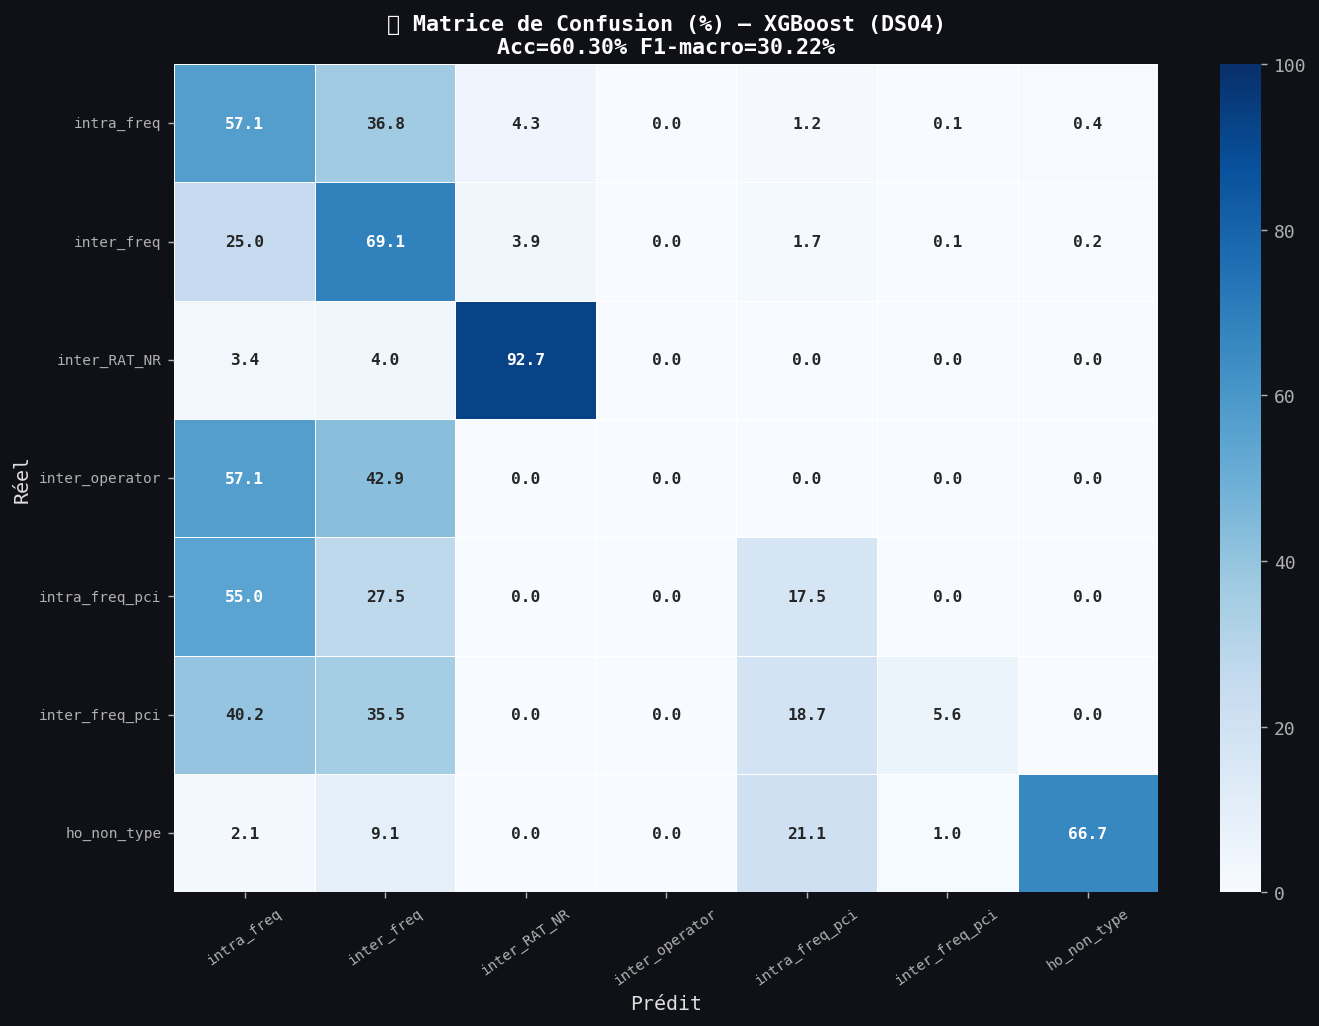

  Précision moy. par type HO: 44.1%


In [6]:
# ── Matrice de Confusion % — XGBoost ─────────────────────────
# ✅ CORRECTION: normalisée en % par ligne
cm_xgb     = confusion_matrix(
    y_test, y_pred_xgb, labels=list(range(N_CLASSES))
)
cm_xgb_pct = cm_xgb.astype('float') / (
    cm_xgb.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cm_xgb_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
ax.set_title(
    f'📊 Matrice de Confusion (%) — XGBoost (DSO4)\n'
    f'Acc={metrics_xgb["accuracy"]*100:.2f}% '
    f'F1-macro={metrics_xgb["f1_macro"]*100:.2f}%',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_xgb_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
print(f'  Précision moy. par type HO: {np.diag(cm_xgb_pct).mean():.1f}%')

---
## Section 3 — M2 : LightGBM


In [7]:
print('='*60+'\n  M2 — LightGBM DSO4\n'+'='*60)

lgbm_d4 = LGBMClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.08,
    num_leaves=127, subsample=0.8, colsample_bytree=0.8,
    objective='multiclass', num_class=N_CLASSES,
    metric='multi_logloss', class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_d4.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(25, verbose=False),
        lgb.log_evaluation(40)
    ]
)
y_pred_lgbm = lgbm_d4.predict(X_test)
print(classification_report(
    y_test, y_pred_lgbm,
    target_names=CLASS_NAMES, zero_division=0
))
metrics_lgbm = {
    'model':       'LightGBM',
    'accuracy':    round(accuracy_score(y_test, y_pred_lgbm), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_lgbm, average='macro',    zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_lgbm, average='weighted', zero_division=0), 4)
}
with open(os.path.join(MODEL_OUT_DIR,'lgbm_dso4.pkl'),'wb') as f:
    pickle.dump(lgbm_d4, f)
print(f"  LightGBM Acc={metrics_lgbm['accuracy']} F1-macro={metrics_lgbm['f1_macro']}")

  M2 — LightGBM DSO4
[40]	valid_0's multi_logloss: 0.474142
[80]	valid_0's multi_logloss: 0.381072
[120]	valid_0's multi_logloss: 0.359184
                precision    recall  f1-score   support

    intra_freq       0.86      0.59      0.70    106710
    inter_freq       0.34      0.66      0.45     33841
  inter_RAT_NR       0.26      0.84      0.40       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.01      0.10      0.01        40
inter_freq_pci       0.01      0.02      0.02       107
   ho_non_type       0.94      0.97      0.95      5071

      accuracy                           0.62    146321
     macro avg       0.35      0.45      0.36    146321
  weighted avg       0.74      0.62      0.65    146321

  LightGBM Acc=0.6213 F1-macro=0.3611


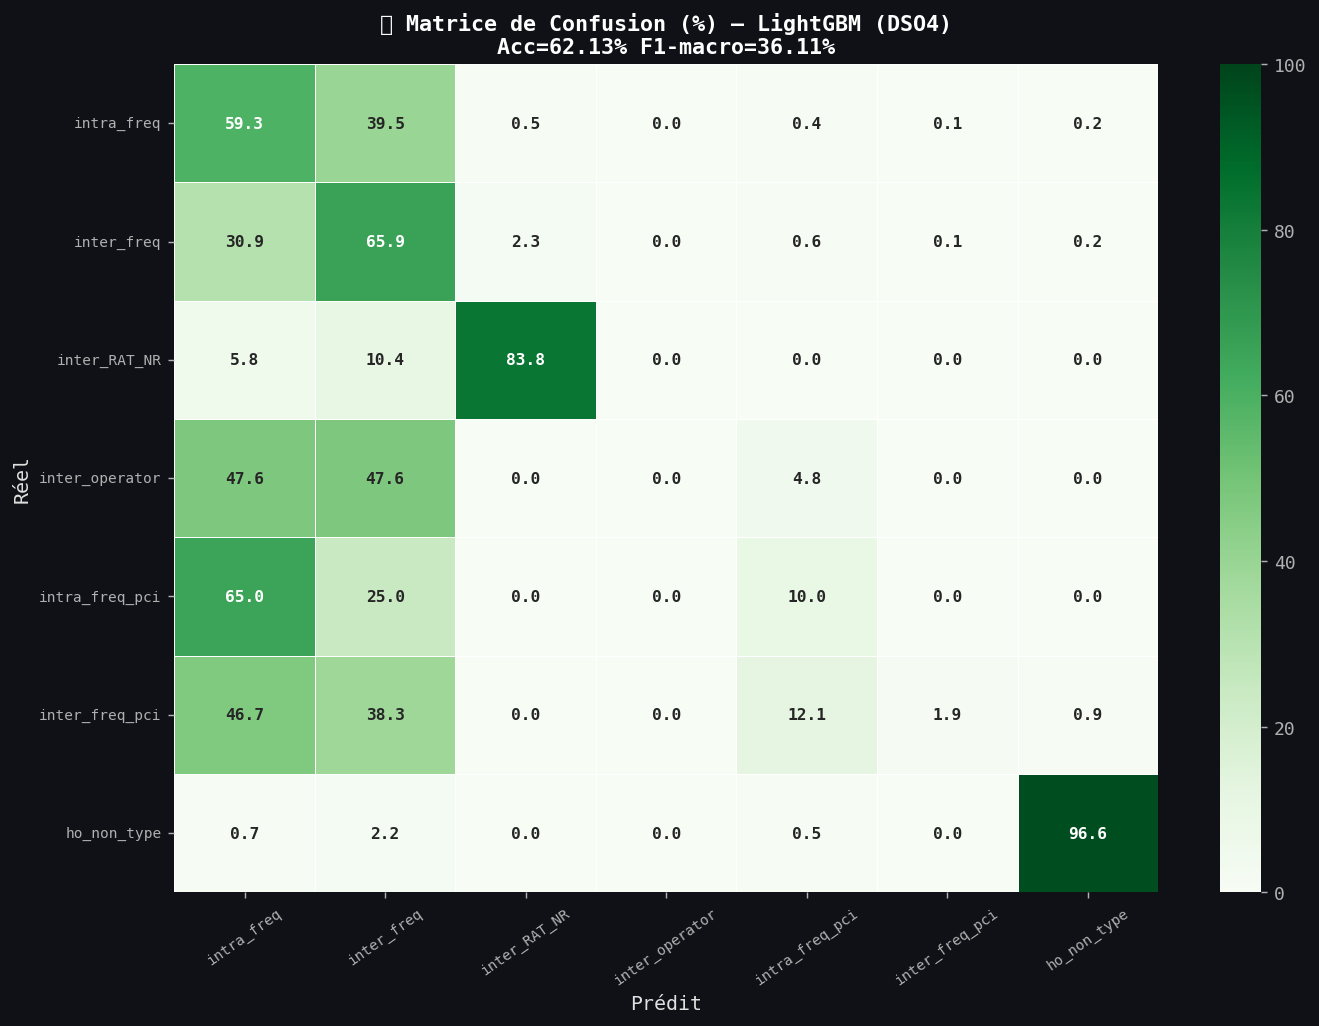

  Précision moy. par type HO: 45.4%


In [8]:
# ── Matrice de Confusion % — LightGBM ────────────────────────
cm_lgbm     = confusion_matrix(
    y_test, y_pred_lgbm, labels=list(range(N_CLASSES))
)
cm_lgbm_pct = cm_lgbm.astype('float') / (
    cm_lgbm.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cm_lgbm_pct, annot=True, fmt='.1f', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
ax.set_title(
    f'📊 Matrice de Confusion (%) — LightGBM (DSO4)\n'
    f'Acc={metrics_lgbm["accuracy"]*100:.2f}% '
    f'F1-macro={metrics_lgbm["f1_macro"]*100:.2f}%',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
print(f'  Précision moy. par type HO: {np.diag(cm_lgbm_pct).mean():.1f}%')

---
## Section 4 — M3 : Random Forest


In [9]:
print('='*60+'\n  M3 — Random Forest DSO4\n'+'='*60)

rf_d4 = RandomForestClassifier(
    n_estimators=250, max_depth=18,
    min_samples_leaf=5, max_features='sqrt',
    class_weight='balanced_subsample',
    max_samples=0.4, random_state=42,
    n_jobs=-1, verbose=1
)
rf_d4.fit(X_train, y_train)
y_pred_rf = rf_d4.predict(X_test)
print(classification_report(
    y_test, y_pred_rf,
    target_names=CLASS_NAMES, zero_division=0
))
metrics_rf = {
    'model':       'Random Forest',
    'accuracy':    round(accuracy_score(y_test, y_pred_rf), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_rf, average='macro',    zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_rf, average='weighted', zero_division=0), 4)
}
with open(os.path.join(MODEL_OUT_DIR,'rf_dso4.pkl'),'wb') as f:
    pickle.dump(rf_d4, f)
print(f"  RF Acc={metrics_rf['accuracy']} F1-macro={metrics_rf['f1_macro']}")

  M3 — Random Forest DSO4


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:   21.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 250 out of 250 | elapsed:    0.9s finished


                precision    recall  f1-score   support

    intra_freq       0.81      0.86      0.83    106710
    inter_freq       0.49      0.45      0.47     33841
  inter_RAT_NR       0.36      0.22      0.27       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.11      0.12      0.11        40
inter_freq_pci       0.33      0.01      0.02       107
   ho_non_type       1.00      0.10      0.19      5071

      accuracy                           0.74    146321
     macro avg       0.44      0.25      0.27    146321
  weighted avg       0.74      0.74      0.72    146321

  RF Acc=0.7374 F1-macro=0.2705


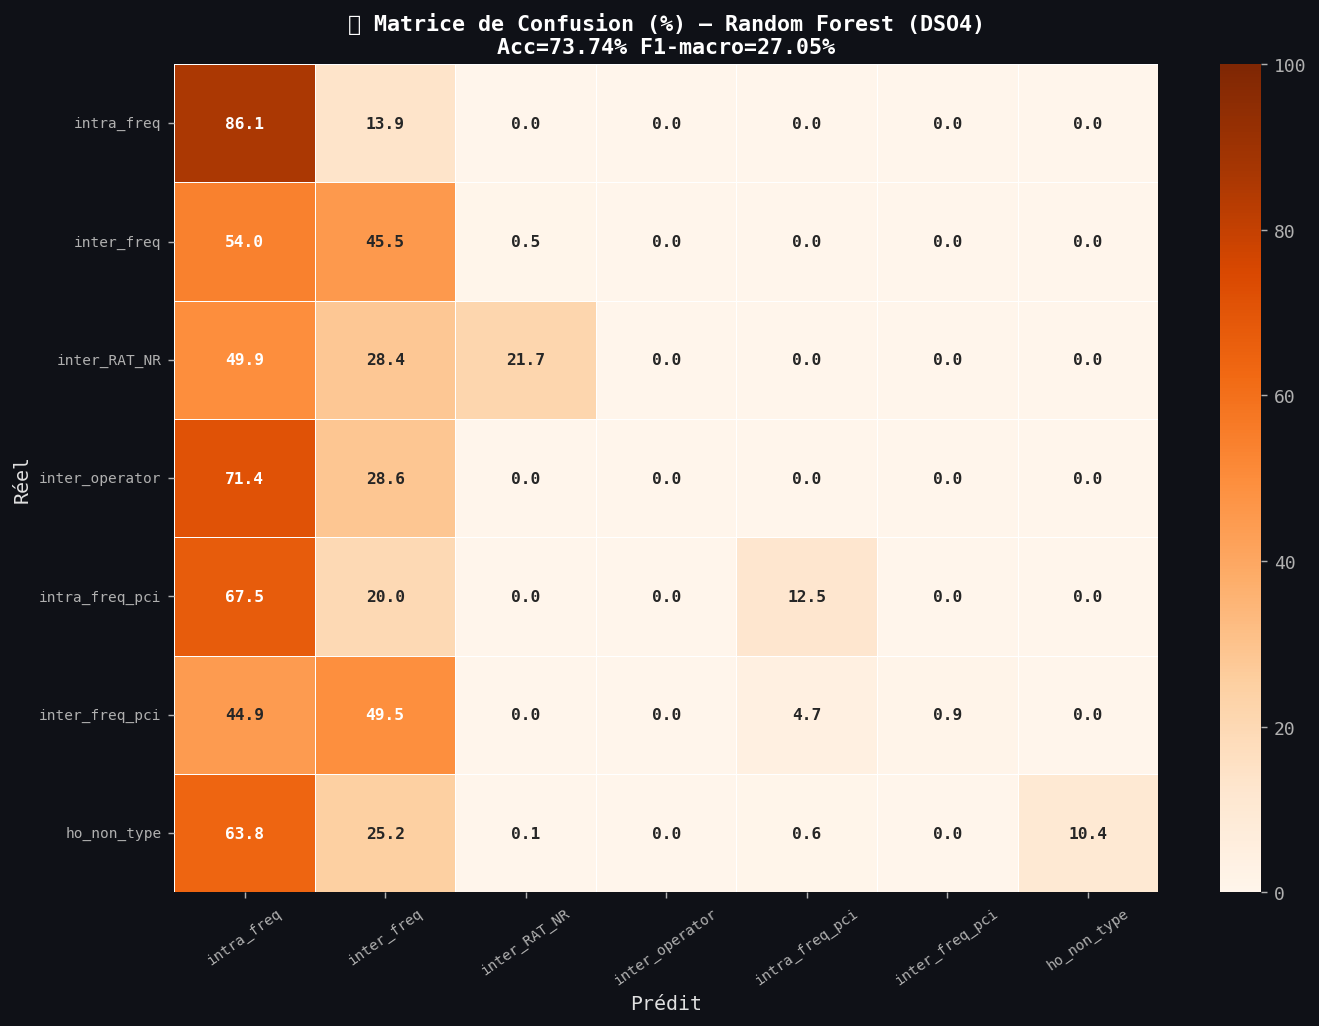

  Précision moy. par type HO: 25.3%


In [10]:
# ── Matrice de Confusion % — Random Forest ───────────────────
cm_rf     = confusion_matrix(
    y_test, y_pred_rf, labels=list(range(N_CLASSES))
)
cm_rf_pct = cm_rf.astype('float') / (
    cm_rf.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cm_rf_pct, annot=True, fmt='.1f', cmap='Oranges',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
ax.set_title(
    f'📊 Matrice de Confusion (%) — Random Forest (DSO4)\n'
    f'Acc={metrics_rf["accuracy"]*100:.2f}% '
    f'F1-macro={metrics_rf["f1_macro"]*100:.2f}%',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_rf_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
print(f'  Précision moy. par type HO: {np.diag(cm_rf_pct).mean():.1f}%')

---
## Section 5 — M4 : BiLSTM Softmax


In [11]:
print('='*60+'\n  M4 — BiLSTM DSO4\n'+'='*60)

# ✅ CORRECTION BUG: '_t-{k}' → '_T{k}'
WINDOW_COLS = [
    c for c in COLS_X
    if any(f'_T{k}' in c for k in range(1, 6))  # ← CORRIGÉ
]
print(f'  WINDOW_COLS: {len(WINDOW_COLS)} colonnes')

T = 5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx   = [list(COLS_X).index(c) for c in WINDOW_COLS]
    F       = len(w_idx) // T
    X_tr_3d = X_train[:, w_idx].reshape(-1, T, F)
    X_va_3d = X_val[:,   w_idx].reshape(-1, T, F)
    X_te_3d = X_test[:,  w_idx].reshape(-1, T, F)
else:
    print('  ⚠️ WINDOW_COLS vide → fallback T=1')
    F       = X_train.shape[1]; T = 1
    X_tr_3d = X_train.reshape(-1, 1, F)
    X_va_3d = X_val.reshape(-1,   1, F)
    X_te_3d = X_test.reshape(-1,  1, F)

print(f'  Shape 3D: {X_tr_3d.shape}')

y_tr_cat = to_categorical(y_train, N_CLASSES)
y_va_cat = to_categorical(y_val,   N_CLASSES)

tf.random.set_seed(42)
inp = Input(shape=(T, F))
x   = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(inp)
x   = BatchNormalization()(x)
x   = Bidirectional(LSTM(64, return_sequences=False, dropout=0.2))(x)
x   = BatchNormalization()(x)
x   = Dense(128, activation='relu')(x)
x   = Dropout(0.35)(x)
x   = Dense(64, activation='relu')(x)
out = Dense(N_CLASSES, activation='softmax')(x)

lstm_d4 = Model(inputs=inp, outputs=out, name='LSTM_DSO4')
lstm_d4.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_d4 = lstm_d4.fit(
    X_tr_3d, y_tr_cat,
    validation_data=(X_va_3d, y_va_cat),
    class_weight=cw_dict,
    epochs=30, batch_size=1024, verbose=1,
    callbacks=[
        EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6
        ),
        ModelCheckpoint(
            os.path.join(MODEL_OUT_DIR,'lstm_dso4_best.h5'),
            monitor='val_accuracy',
            save_best_only=True, mode='max'
        )
    ]
)

y_proba_lstm = lstm_d4.predict(
    X_te_3d, batch_size=2048, verbose=0
)
y_pred_lstm = y_proba_lstm.argmax(axis=1)
print(classification_report(
    y_test, y_pred_lstm,
    target_names=CLASS_NAMES, zero_division=0
))
metrics_lstm = {
    'model':       'BiLSTM',
    'accuracy':    round(accuracy_score(y_test, y_pred_lstm), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_lstm, average='macro',    zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_lstm, average='weighted', zero_division=0), 4)
}
lstm_d4.save(os.path.join(MODEL_OUT_DIR,'lstm_dso4.h5'))
print(f"  BiLSTM Acc={metrics_lstm['accuracy']} F1-macro={metrics_lstm['f1_macro']}")

  M4 — BiLSTM DSO4
  WINDOW_COLS: 45 colonnes
  Shape 3D: (682825, 5, 9)
Epoch 1/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.4465 - loss: 2.1018  

667/667 ━━━━━━━━━━━━━━━━━━━━ 105s 137ms/step - accuracy: 0.4868 - loss: 2.2707 - val_accuracy: 0.7393 - val_loss: 1.6902 - learning_rate: 0.0010
Epoch 2/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.5878 - loss: 1.8624  

667/667 ━━━━━━━━━━━━━━━━━━━━ 95s 142ms/step - accuracy: 0.5841 - loss: 2.0751 - val_accuracy: 0.7801 - val_loss: 1.5251 - learning_rate: 0.0010
Epoch 3/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 96s 143ms/step - accuracy: 0.5879 - loss: 2.0395 - val_accuracy: 0.6965 - val_loss: 1.6027 - learning_rate: 0.0010
Epoch 4/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 95s 142ms/step - accuracy: 0.6554 - loss: 1.9232 - val_accuracy: 0.7141 - val_loss: 1.3881 - learning_rate: 0.0010
Epoch 5/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 95s 142ms/step - accuracy: 0.6583 - loss: 1.7507 - val_accuracy: 0.7158 - val_loss: 1.5641 - learning_rate: 0.0010
Epoch 6/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 92s 138ms/step - accuracy: 0.6288 - loss: 1.8593 - val_accuracy: 0.7060 - val_loss: 1.3581 - learning_rate: 0.0010
Epoch 7/30
667/667 ━━━━━━━━━━━━━━━━━━━━ 510s 765ms/step - accuracy: 0.6394 - loss: 1.6988 - val_accuracy: 0.1545 - val_loss: 1.4730 - learning_rate: 0.0010


                precision    recall  f1-score   support

    intra_freq       0.78      0.84      0.81    106710
    inter_freq       0.14      0.00      0.00     33841
  inter_RAT_NR       0.01      0.00      0.00       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.00      0.00        40
inter_freq_pci       0.00      0.06      0.00       107
   ho_non_type       0.11      0.60      0.19      5071

      accuracy                           0.63    146321
     macro avg       0.15      0.21      0.14    146321
  weighted avg       0.60      0.63      0.60    146321

  BiLSTM Acc=0.6328 F1-macro=0.1433


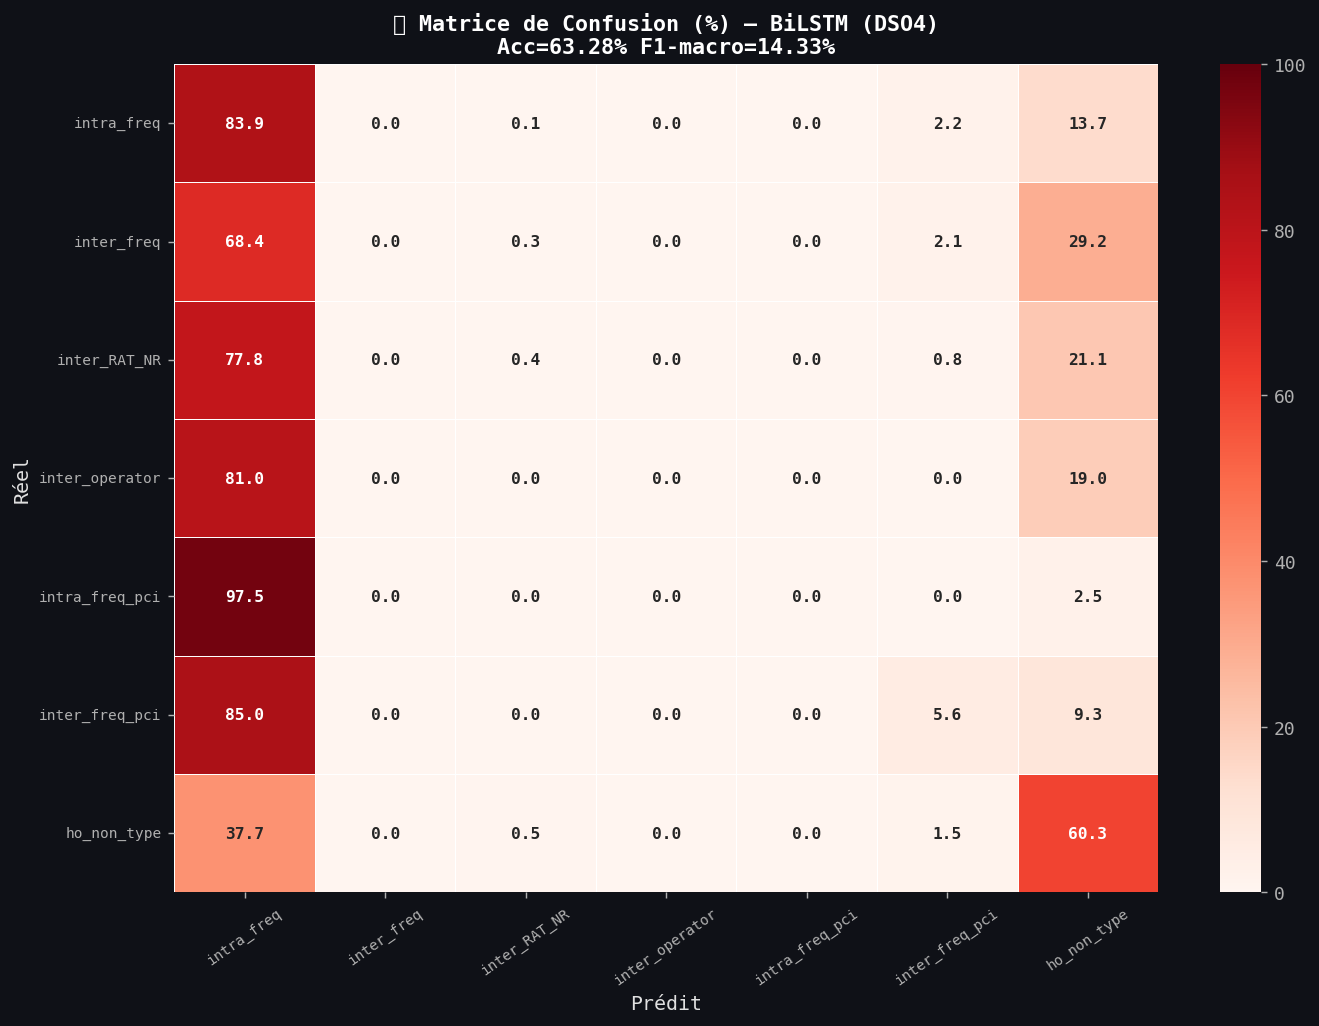

  Précision moy. par type HO: 21.5%


In [12]:
# ── Matrice de Confusion % — BiLSTM ──────────────────────────
cm_lstm     = confusion_matrix(
    y_test, y_pred_lstm, labels=list(range(N_CLASSES))
)
cm_lstm_pct = cm_lstm.astype('float') / (
    cm_lstm.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cm_lstm_pct, annot=True, fmt='.1f', cmap='Reds',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
ax.set_title(
    f'📊 Matrice de Confusion (%) — BiLSTM (DSO4)\n'
    f'Acc={metrics_lstm["accuracy"]*100:.2f}% '
    f'F1-macro={metrics_lstm["f1_macro"]*100:.2f}%',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_lstm_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
print(f'  Précision moy. par type HO: {np.diag(cm_lstm_pct).mean():.1f}%')

---
## Section 6 — M5 : TabNet


In [13]:
print('='*60+'\n  M5 — TabNet DSO4\n'+'='*60)

# ── 1. float32 + sampling ─────────────────────────────────────
N_TN       = min(100_000, len(X_train))
idx_tn     = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn    = X_train[idx_tn].astype(np.float32)
X_va_tn    = X_val.astype(np.float32)
X_te_tn    = X_test.astype(np.float32)
y_train_tn = y_train[idx_tn]
print(f'Sample train: {len(X_tr_tn):,}')

# ── 2. Pretraining ────────────────────────────────────────────
pt_d4 = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=5, seed=42
)
pt_d4.fit(
    X_train=X_tr_tn,
    eval_set=[X_va_tn],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    pretraining_ratio=0.5
)

# ── 3. Modèle supervisé ───────────────────────────────────────
tabnet_d4 = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# Mini-fit pour initialiser
tabnet_d4.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512, virtual_batch_size=512
)
tabnet_d4.load_weights_from_unsupervised(pt_d4)

# ── 4. Entraînement réel ──────────────────────────────────────
tabnet_d4.verbose = 10
tabnet_d4.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['accuracy'],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    weights=1
)

y_pred_tn = tabnet_d4.predict(X_te_tn)
print(classification_report(
    y_test, y_pred_tn,
    target_names=CLASS_NAMES, zero_division=0
))
metrics_tn = {
    'model':       'TabNet',
    'accuracy':    round(accuracy_score(y_test, y_pred_tn), 4),
    'f1_macro':    round(f1_score(y_test, y_pred_tn, average='macro',    zero_division=0), 4),
    'f1_weighted': round(f1_score(y_test, y_pred_tn, average='weighted', zero_division=0), 4)
}
tabnet_d4.save_model(os.path.join(MODEL_OUT_DIR,'tabnet_dso4'))
print(f"  TabNet Acc={metrics_tn['accuracy']} F1-macro={metrics_tn['f1_macro']}")

  M5 — TabNet DSO4
Sample train: 100,000
epoch 0  | loss: 67818.86735| val_0_unsup_loss_numpy: 56594.83203125|  0:00:54s
epoch 5  | loss: 62.46064| val_0_unsup_loss_numpy: 856.5628051757812|  0:05:35s

Early stopping occurred at epoch 9 with best_epoch = 4 and best_val_0_unsup_loss_numpy = 612.5250854492188
epoch 0  | loss: 1.66809 | val_0_accuracy: 0.01599 |  0:00:44s
epoch 10 | loss: 0.02445 | val_0_accuracy: 0.73386 |  0:06:46s

Early stopping occurred at epoch 12 with best_epoch = 7 and best_val_0_accuracy = 0.74741
                precision    recall  f1-score   support

    intra_freq       0.73      0.48      0.58    106710
    inter_freq       0.24      0.25      0.24     33841
  inter_RAT_NR       0.01      0.09      0.01       531
inter_operator       0.00      0.00      0.00        21
intra_freq_pci       0.00      0.05      0.00        40
inter_freq_pci       0.00      0.06      0.00       107
   ho_non_type       0.00      0.00      0.00      5071

      accuracy          

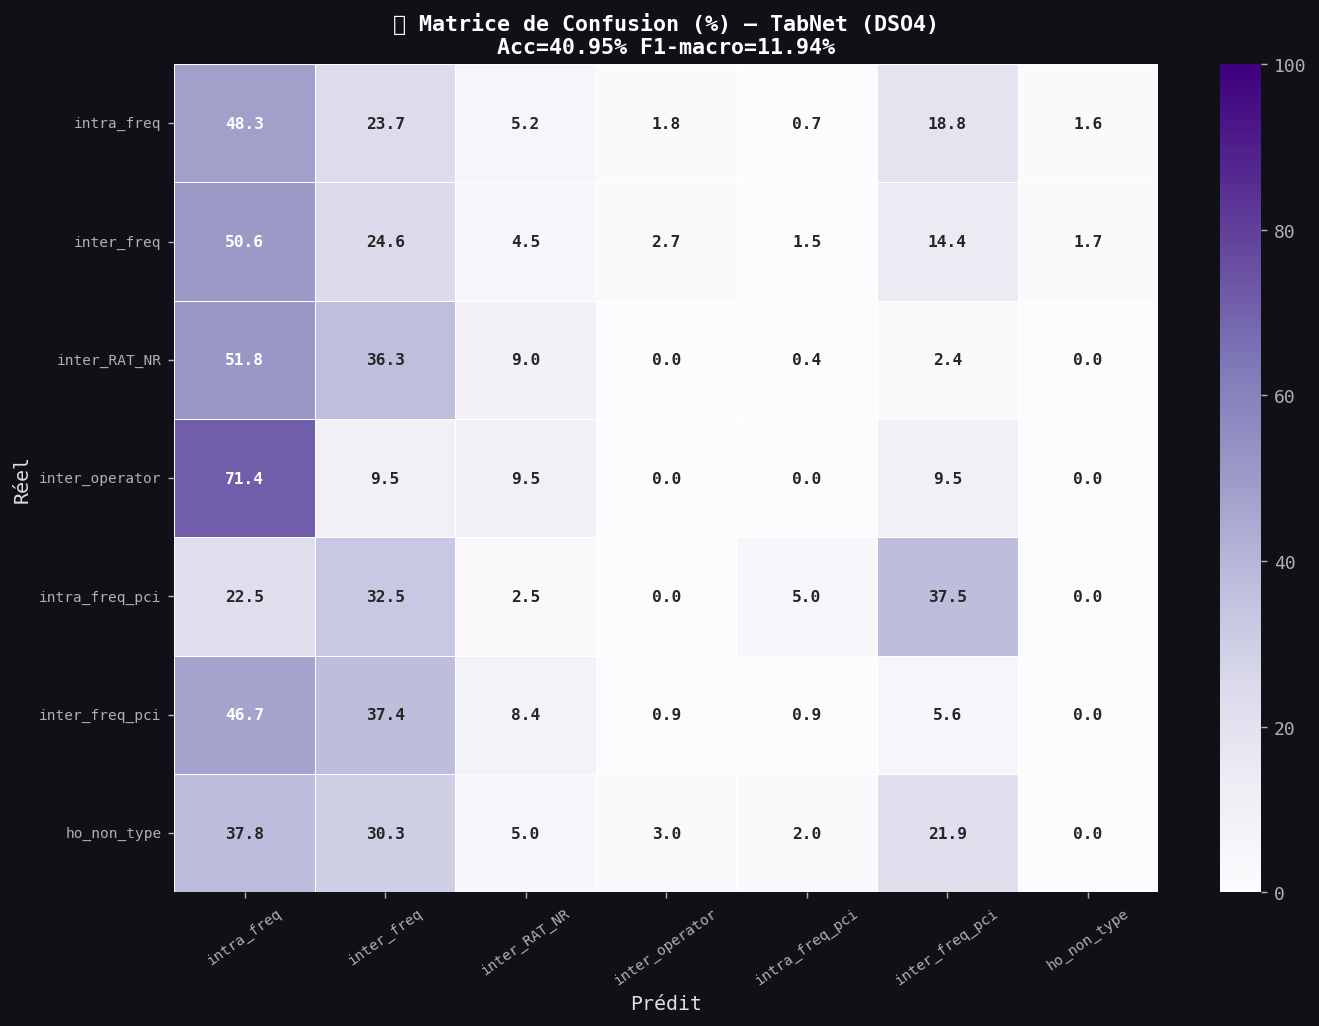

  Précision moy. par type HO: 13.2%


In [14]:
# ── Matrice de Confusion % — TabNet ──────────────────────────
cm_tn     = confusion_matrix(
    y_test, y_pred_tn, labels=list(range(N_CLASSES))
)
cm_tn_pct = cm_tn.astype('float') / (
    cm_tn.sum(axis=1, keepdims=True) + 1e-9
) * 100

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    cm_tn_pct, annot=True, fmt='.1f', cmap='Purples',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.4, ax=ax,
    annot_kws={'size': 9, 'weight': 'bold'},
    vmin=0, vmax=100
)
ax.set_xlabel('Prédit', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.tick_params(axis='x', rotation=35, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
ax.set_title(
    f'📊 Matrice de Confusion (%) — TabNet (DSO4)\n'
    f'Acc={metrics_tn["accuracy"]*100:.2f}% '
    f'F1-macro={metrics_tn["f1_macro"]*100:.2f}%',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()
print(f'  Précision moy. par type HO: {np.diag(cm_tn_pct).mean():.1f}%')

---
## Section 7 — Grille comparative & Dashboard Final


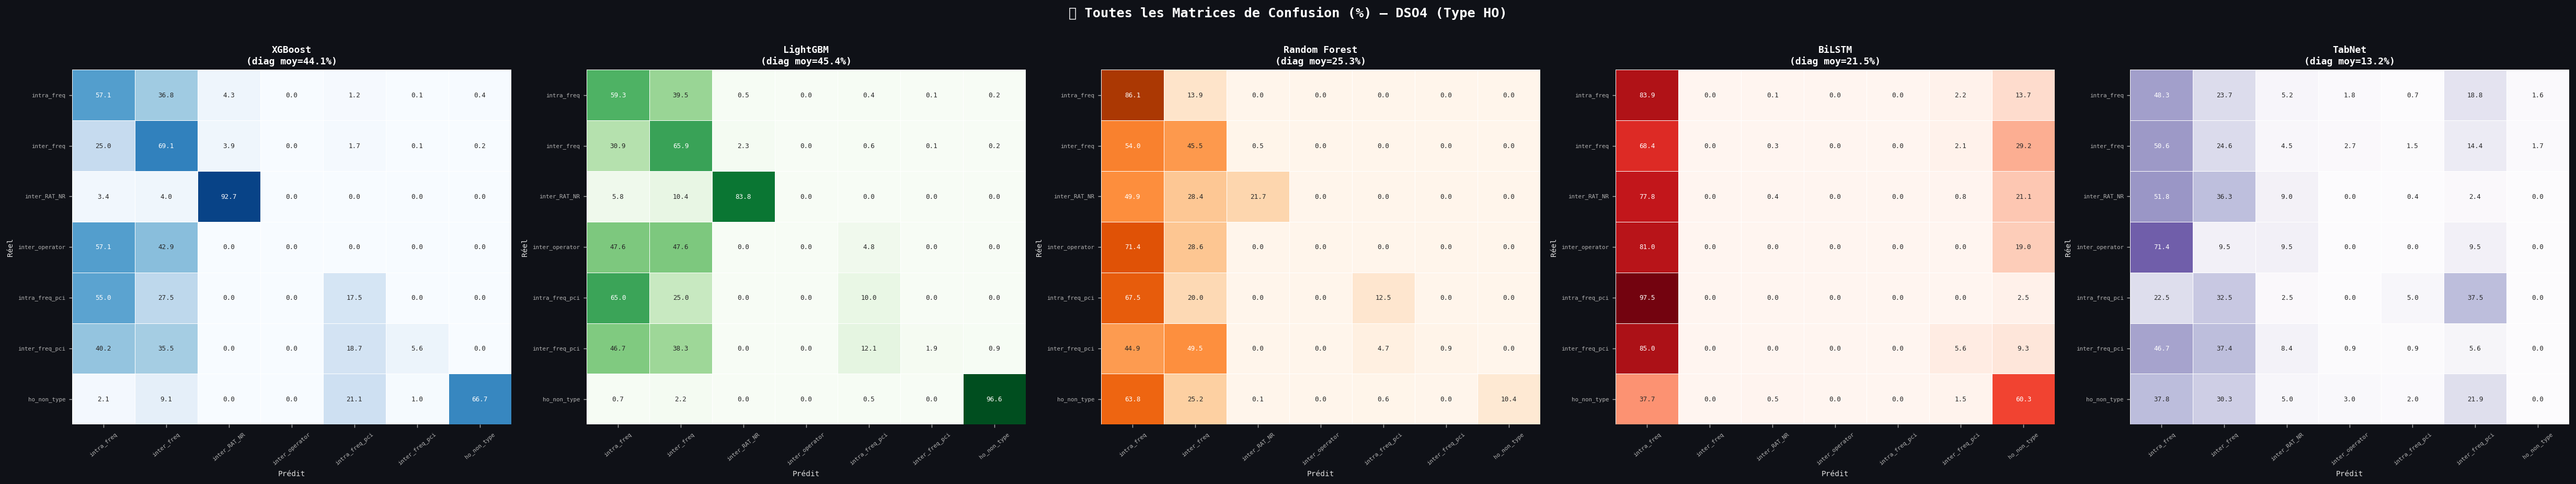


=== RÉSULTATS DSO4 ===
               accuracy  f1_macro  f1_weighted
model                                         
XGBoost          0.6030    0.3022       0.6422
LightGBM         0.6213    0.3611       0.6501
Random Forest    0.7374    0.2705       0.7240
BiLSTM           0.6328    0.1433       0.5951
TabNet           0.4095    0.1194       0.4788

🏆 Meilleur (F1-macro) : LightGBM → 0.3611


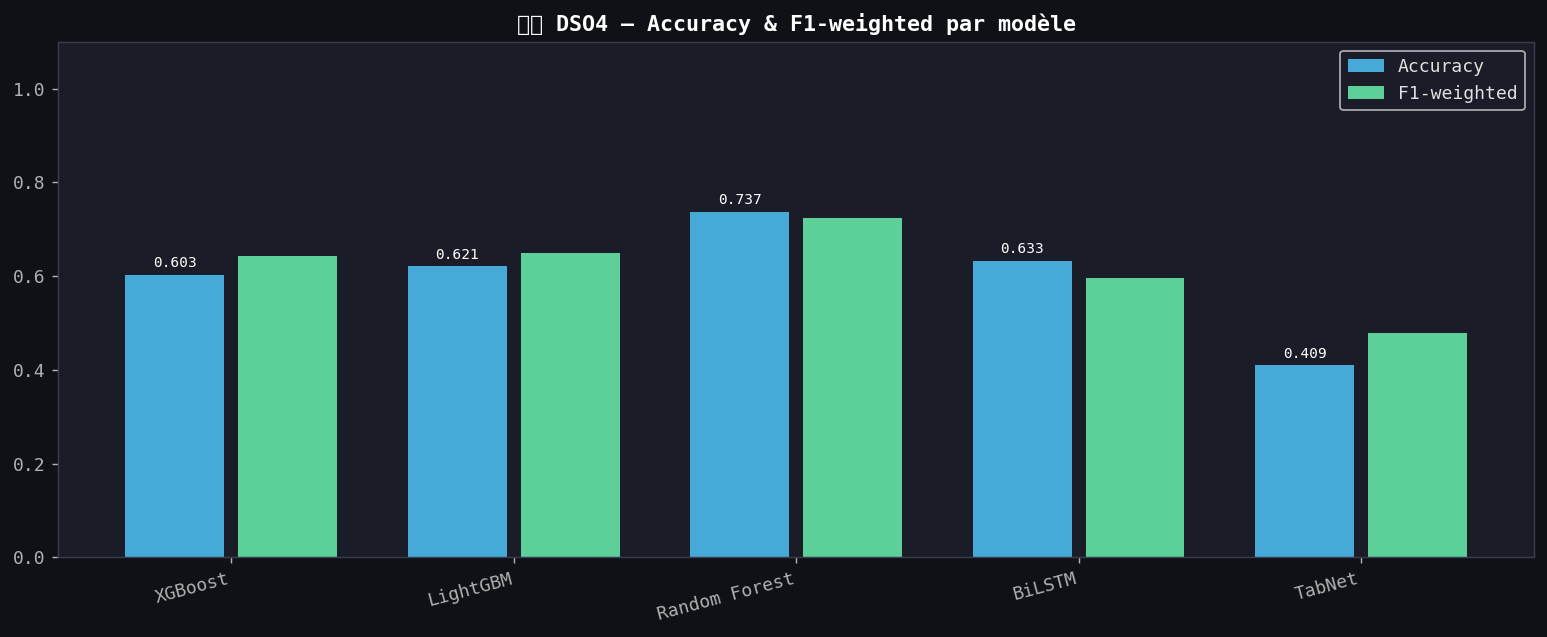


✅ results_dso4.json sauvegardé

🎉 Pipeline complet : NB1→NB2→NB3→DSO1→DSO2→DSO3→DSO4 ✅


In [15]:
# ── Grille 1×5 en % — toutes les matrices côte à côte ────────
# ✅ CORRECTION: grille aussi en pourcentage
fig, axes = plt.subplots(1, 5, figsize=(38, 7))
models_cm = [
    ('XGBoost',      cm_xgb_pct,  'Blues'),
    ('LightGBM',     cm_lgbm_pct, 'Greens'),
    ('Random Forest',cm_rf_pct,   'Oranges'),
    ('BiLSTM',       cm_lstm_pct, 'Reds'),
    ('TabNet',       cm_tn_pct,   'Purples')
]
for ax, (name, cm_pct, cmap) in zip(axes, models_cm):
    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap=cmap,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.3, ax=ax,
        annot_kws={'size': 7}, cbar=False,
        vmin=0, vmax=100
    )
    diag = np.diag(cm_pct).mean()
    ax.set_title(
        f'{name}\n(diag moy={diag:.1f}%)',
        fontsize=10, fontweight='bold'
    )
    ax.tick_params(axis='x', rotation=40, labelsize=6)
    ax.tick_params(axis='y', labelsize=6)
    ax.set_xlabel('Prédit', fontsize=8)
    ax.set_ylabel('Réel', fontsize=8)

plt.suptitle(
    '📊 Toutes les Matrices de Confusion (%) — DSO4 (Type HO)',
    fontsize=14, fontweight='bold', color='white', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'cm_all_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()

# ── Dashboard final ───────────────────────────────────────────
all_metrics  = [metrics_xgb, metrics_lgbm, metrics_rf,
                metrics_lstm, metrics_tn]
df_results   = pd.DataFrame(all_metrics).set_index('model')
print('\n=== RÉSULTATS DSO4 ===')
print(df_results.to_string())

best = df_results['f1_macro'].idxmax()
print(f'\n🏆 Meilleur (F1-macro) : {best} → {df_results.loc[best,"f1_macro"]:.4f}')

x           = np.arange(5)
models_list = ['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x-0.2, df_results['accuracy'],    0.35,
               label='Accuracy',     color=BLUE,  alpha=0.85)
bars2 = ax.bar(x+0.2, df_results['f1_weighted'],  0.35,
               label='F1-weighted',  color=GREEN, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_title('🏷️ DSO4 — Accuracy & F1-weighted par modèle',
             fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8, color='white'
    )

plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_OUT_DIR,'dashboard_dso4.png'),
    bbox_inches='tight', facecolor='#0F1117'
)
plt.show()

# ✅ même nom que l'original
with open(os.path.join(MODEL_OUT_DIR,'results_dso4.json'),'w') as f:
    json.dump(all_metrics, f, indent=2)

print('\n✅ results_dso4.json sauvegardé')
print('\n🎉 Pipeline complet : NB1→NB2→NB3→DSO1→DSO2→DSO3→DSO4 ✅')

---
## Bilan NB4 DSO4 — Corrigé

### 📊 Label DSO4
```
ho_type_enc = type HO (NB2 FE-2)
Filtré sur handover==1 uniquement
Multi-classes: intra_freq, inter_freq, inter_RAT_NR...
Métriques: Accuracy, F1-macro, F1-weighted
```

### ✅ Corrections
| Correction | Avant | Après |
|------------|-------|-------|
| Matrices CM | Valeurs absolues | ✅ En % par ligne |
| Grille finale | Valeurs absolues | ✅ En % avec diag moy |
| BiLSTM cols | `_t-{k}` (bug) | ✅ `_T{k}` (format NB2) |
| cluster_id | Non vérifié | ✅ Assert présent |
| Titre CM | Sans métriques | ✅ Acc + F1-macro dans titre |

### 💾 Fichiers produits
```
MODEL_output/DSO4/
  xgb_dso4.pkl    lgbm_dso4.pkl
  rf_dso4.pkl     lstm_dso4.h5
  tabnet_dso4.zip results_dso4.json
  cm_xgb_dso4.png   cm_lgbm_dso4.png
  cm_rf_dso4.png    cm_lstm_dso4.png
  cm_tabnet_dso4.png cm_all_dso4.png
  dashboard_dso4.png
```
